In [3]:
"""
Practice plotting DESC flux surfaces in 2D and 3D.

Run:
    python practice_desc_flux_surfaces.py
"""

import numpy as np
import matplotlib.pyplot as plt

from desc.examples import get
from desc.grid import LinearGrid
from desc.plotting import plot_surfaces, plot_3d


# ------------------------------------------------------------
# 1. Load a DESC example equilibrium
# ------------------------------------------------------------
eq = get("HELIOTRON")
print(eq)

Equilibrium at 0x20e6e876090 (L=24, M=12, N=3, NFP=19, sym=True, spectral_indexing=fringe)


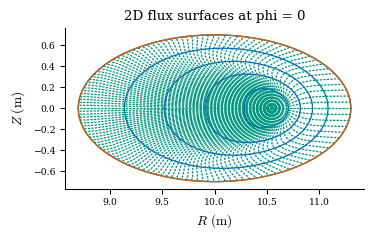

In [5]:
# ------------------------------------------------------------
# 2. Built-in DESC 2D flux-surface plot
# ------------------------------------------------------------
rho_values = np.linspace(0.2, 1.0, 5)

fig, ax = plot_surfaces(
    eq,
    rho=rho_values,
    theta=128,
    phi=[0.0],
)

ax[0].set_title("2D flux surfaces at phi = 0")
plt.show()

C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\DESC\desc\utils.py:563: UserWarning: Unequal number of field periods for grid 1 and basis 19.
  warnings.warn(msg, err)
C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\DESC\desc\utils.py:563: UserWarning: Unequal number of field periods for grid 1 and basis 19.
  warnings.warn(msg, err)
C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\DESC\desc\utils.py:563: UserWarning: Unequal number of field periods for grid 1 and basis 19.
  warnings.warn(msg, err)
C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\DESC\desc\utils.py:563: UserWarning: Unequal number of field periods for grid 1 and basis 19.
  warnings.warn(msg, err)
C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\DESC\desc\utils.py:563: UserWarning: Unequal number of field periods for grid 1 and basis 19.
  warnings.warn(msg, err)
C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\DESC\desc\utils.py:563: UserWarning: Unequal number of field periods for gri

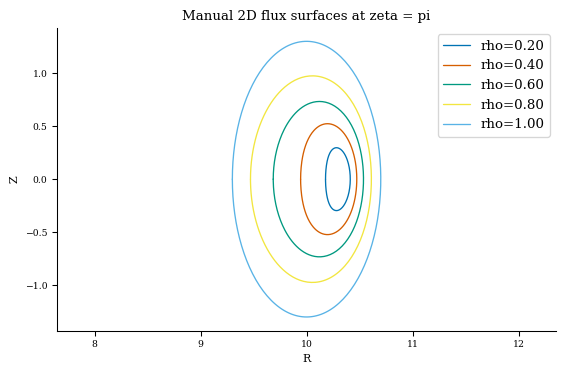

In [13]:
# ------------------------------------------------------------
# 3. Manual 2D plot: compute R and Z yourself
# ------------------------------------------------------------
plt.figure()

for rho in rho_values:
    grid = LinearGrid(
        rho=np.array([rho]),
        theta=np.linspace(0, 2 * np.pi, 200),
        zeta=np.array([np.pi]),
    )

    data = eq.compute(["R", "Z"], grid=grid)

    R = data["R"]
    Z = data["Z"]

    plt.plot(R, Z, label=f"rho={rho:.2f}")

plt.xlabel("R")
plt.ylabel("Z")
plt.axis("equal")
plt.title("Manual 2D flux surfaces at zeta = pi")
plt.legend()
plt.show()

C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\DESC\desc\utils.py:563: UserWarning: Unequal number of field periods for grid 1 and basis 19.
  warnings.warn(msg, err)
C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\DESC\desc\utils.py:563: UserWarning: Unequal number of field periods for grid 1 and basis 19.
  warnings.warn(msg, err)
C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\DESC\desc\utils.py:563: UserWarning: Unequal number of field periods for grid 1 and basis 19.
  warnings.warn(msg, err)
C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\DESC\desc\utils.py:563: UserWarning: Unequal number of field periods for grid 1 and basis 19.
  warnings.warn(msg, err)
C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\DESC\desc\utils.py:563: UserWarning: Unequal number of field periods for grid 1 and basis 19.
  warnings.warn(msg, err)
C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\DESC\desc\utils.py:563: UserWarning: Unequal number of field periods for gri

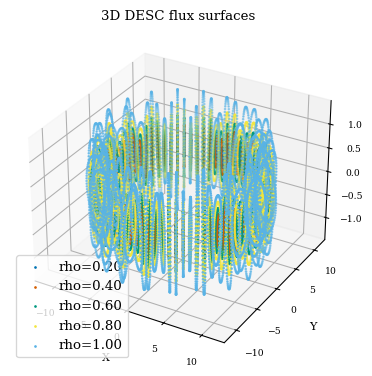

In [11]:
# ------------------------------------------------------------
# 4. Manual 3D plot using x, y, z
# ------------------------------------------------------------
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

for rho in rho_values:
    grid = LinearGrid(
        rho=np.array([rho]),
        theta=np.linspace(0, 2 * np.pi, 80),
        zeta=np.linspace(0, 2 * np.pi, 80),
    )

    data = eq.compute(["R", "phi", "Z"], grid=grid)

    R = data["R"]
    phi = data["phi"]
    Z = data["Z"]

    X = R * np.cos(phi)
    Y = R * np.sin(phi)

    ax.scatter(X, Y, Z, s=1, label=f"rho={rho:.2f}")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("3D DESC flux surfaces")
plt.legend()
plt.show()

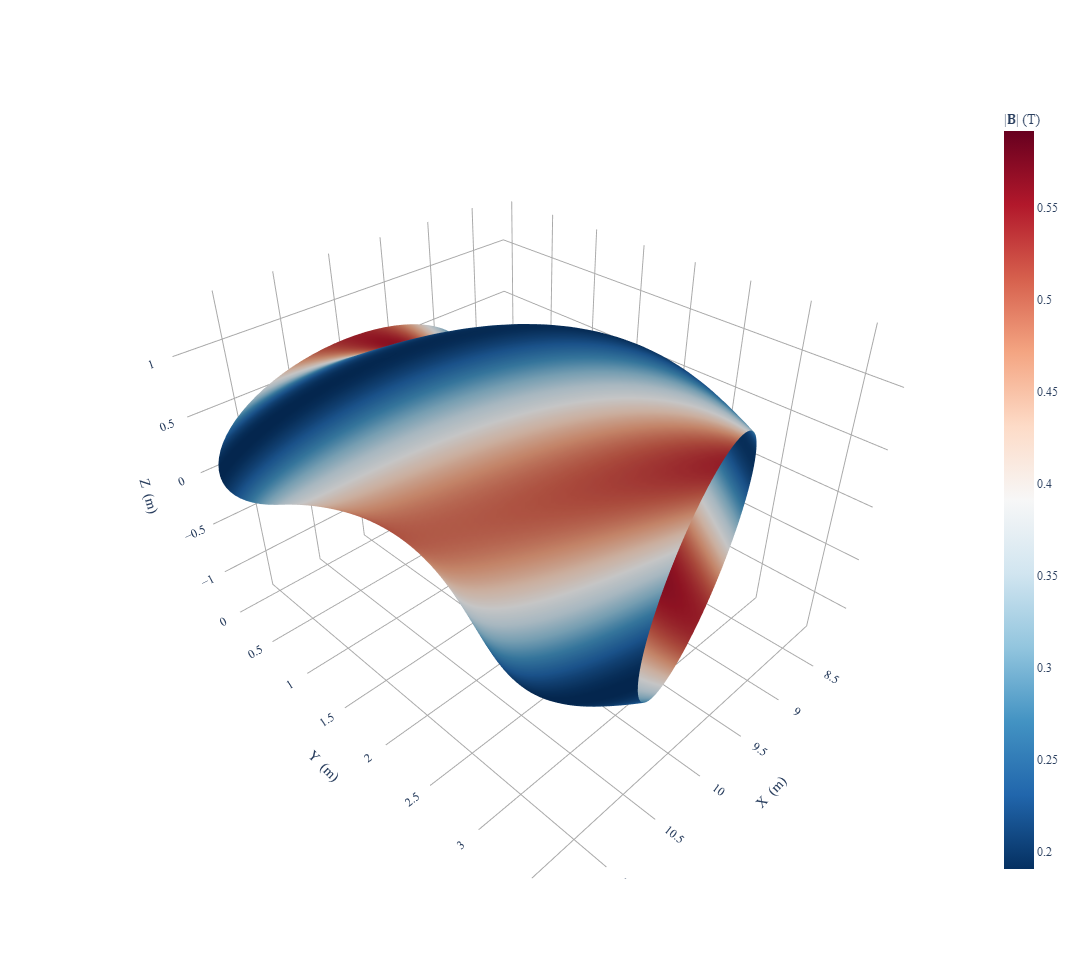

In [12]:
# ------------------------------------------------------------
# 5. Built-in DESC 3D plot
# ------------------------------------------------------------
from desc.grid import LinearGrid
from desc.plotting import plot_3d
import numpy as np

grid = LinearGrid(
    rho=np.array([1.0]),
    theta=np.linspace(0, 2*np.pi, 80),
    zeta=np.linspace(0, 2*np.pi / eq.NFP, 80),
    NFP=eq.NFP,
)

fig = plot_3d(eq, "|B|", grid=grid)
fig.show()